## 1. Описание датасета

**Название:** OpenSky States Snapshot Dataset
**Источник:** https://www.kaggle.com/datasets/ibrahimqasimi/opensky
**Предметная область:** авиация, мониторинг воздушного движения
**Характер данных:** реальные наблюдения (ADS-B сигналы от самолетов)

**Описание:**
Датасет представляет собой снимок состояния воздушного пространства, собранный сетью OpenSky.
Каждая строка соответствует одному самолету, для которого зафиксированы координаты, высота, скорость, направление, страна регистрации и другие параметры.

**Тип задачи:** анализ движения воздушного транспорта, определение плотности трафика, классификация или визуализация маршрутов.

## Атрибуты датасета

| Название атрибута | Тип данных         | Описание |
|--------------------|--------------------|-----------|
| `icao24` | строковый          | Уникальный 24-битный идентификатор самолёта (hex-код ICAO) |
| `callsign` | строковый          | Позывной рейса, передаваемый самолётом (может быть пустым) |
| `origin_country` | строковый          | Страна, в которой зарегистрирован самолёт |
| `time_position` | числовой (float64) | Время последнего позиционного сообщения (в секундах UNIX) |
| `last_contact` | числовой (int64)   | Время последнего контакта с приёмником (в секундах UNIX) |
| `longitude` | числовой (float64) | Географическая долгота текущего положения самолёта |
| `latitude` | числовой (float64) | Географическая широта текущего положения самолёта |
| `baro_altitude` | числовой (float64) | Барометрическая высота полёта (в метрах) |
| `on_ground` | логический (bool)  | Находится ли самолёт на земле (`True`/`False`) |
| `velocity` | числовой (float64) | Горизонтальная скорость полёта (в м/с) |
| `true_track` | числовой (float64) | Азимутальное направление движения (в градусах, 0–360) |
| `vertical_rate` | числовой (float64) | Вертикальная скорость (набор или снижение, в м/с) |
| `sensors` | числовой (float64) | Идентификаторы сенсоров (в этом наборе отсутствуют данные) |
| `geo_altitude` | числовой (float)64 | Геометрическая (GPS) высота над уровнем моря (в метрах) |
| `squawk` | строковый          | Код транспондера (восьмиричный код, используется диспетчерами) |
| `spi` | логический (bool)  | Индикатор приоритета сообщения (Special Purpose Indicator) |
| `position_source` | числовой (int64)   | Источник позиционных данных: 0 = ADS-B, 1 = ASTERIX, 2 = MLAT |


In [6]:
!pip install pandas



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
import pandas as pd

df = pd.read_csv("opensky_states_snapshot.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7420 entries, 0 to 7419
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   icao24           7420 non-null   object 
 1   callsign         7284 non-null   object 
 2   origin_country   7420 non-null   object 
 3   time_position    7359 non-null   float64
 4   last_contact     7420 non-null   int64  
 5   longitude        7359 non-null   float64
 6   latitude         7359 non-null   float64
 7   baro_altitude    6815 non-null   float64
 8   on_ground        7420 non-null   bool   
 9   velocity         7418 non-null   float64
 10  true_track       7420 non-null   float64
 11  vertical_rate    6836 non-null   float64
 12  sensors          0 non-null      float64
 13  geo_altitude     6719 non-null   float64
 14  squawk           4550 non-null   float64
 15  spi              7420 non-null   bool   
 16  position_source  7420 non-null   int64  
dtypes: bool(2), fl

In [127]:
numeric_columns = ['time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'position_source']

result = []

for col in numeric_columns:
    str_mean = df[col].mean()
    str_std = df[col].std()
    result.append({'numeric_columns': col, 'mean': str_mean, 'std': str_std})
print(result)



[{'numeric_columns': 'time_position', 'mean': np.float64(1755600206.5139284), 'std': 215.02587956609668}, {'numeric_columns': 'last_contact', 'mean': np.float64(1755600220.4373314), 'std': 54.712538810670374}, {'numeric_columns': 'longitude', 'mean': np.float64(5.355736499524392), 'std': 65.09693614715577}, {'numeric_columns': 'latitude', 'mean': np.float64(37.429212746297054), 'std': 18.789600124843183}, {'numeric_columns': 'baro_altitude', 'mean': np.float64(7250.561379310345), 'std': 4238.752990132846}, {'numeric_columns': 'velocity', 'mean': np.float64(171.65630088972767), 'std': 84.00496740249338}, {'numeric_columns': 'true_track', 'mean': np.float64(186.8717345013477), 'std': 103.30005984213284}, {'numeric_columns': 'vertical_rate', 'mean': np.float64(-0.012267407840842575), 'std': 5.114120850967535}, {'numeric_columns': 'geo_altitude', 'mean': np.float64(7649.898208066677), 'std': 4395.965823532917}, {'numeric_columns': 'position_source', 'mean': np.float64(0.0), 'std': 0.0}]


Количество пустых значений в time_position: 61


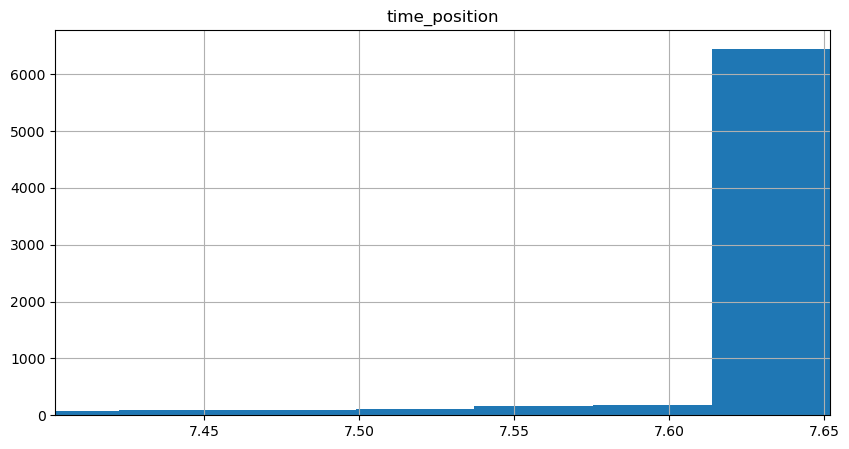

Количество пустых значений в last_contact: 0


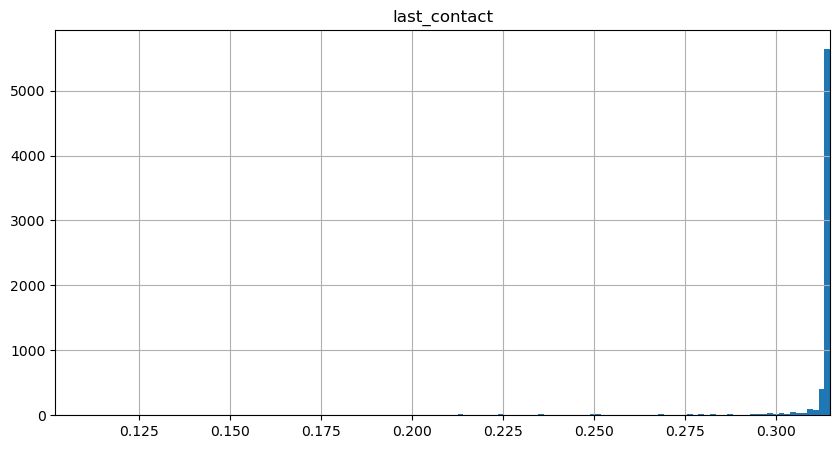

Количество пустых значений в longitude: 61


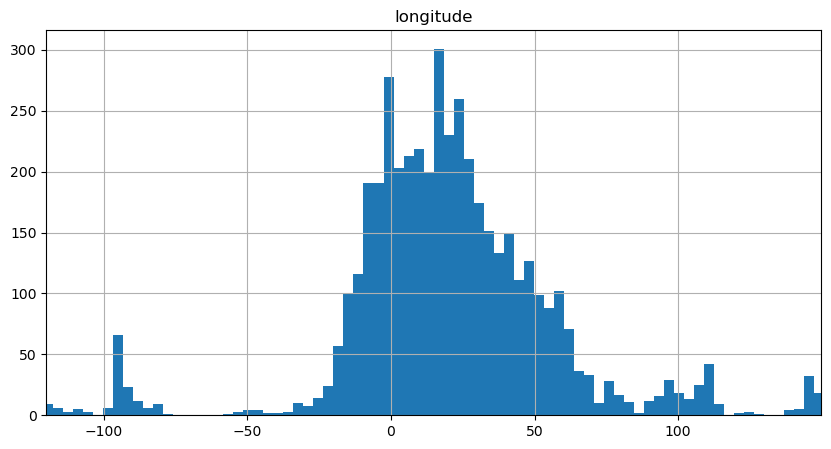

Количество пустых значений в latitude: 61


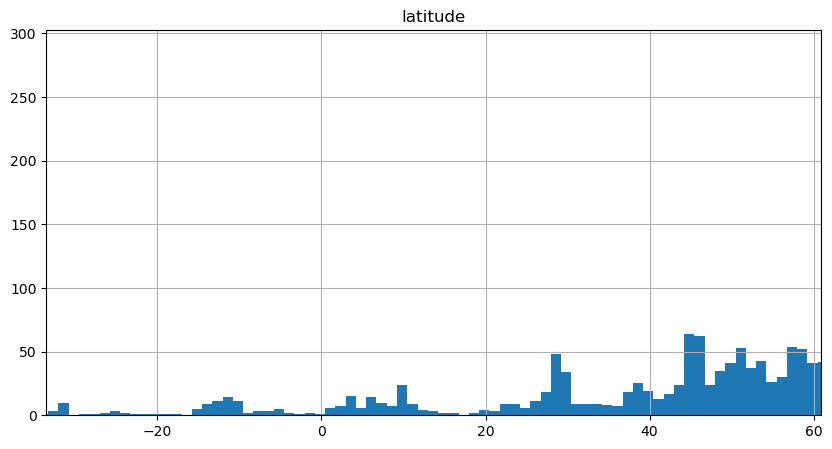

Количество пустых значений в baro_altitude: 605


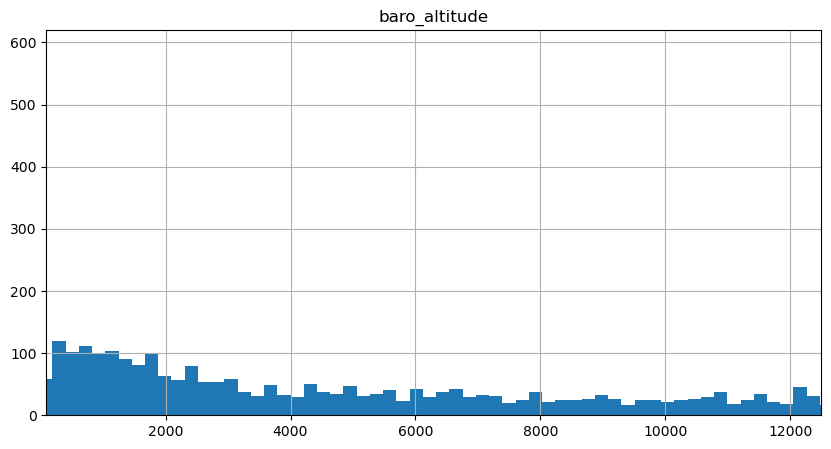

Количество пустых значений в velocity: 2


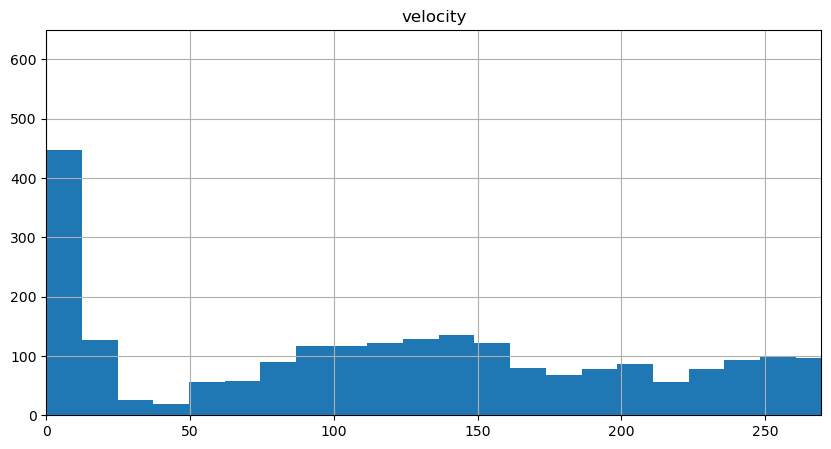

Количество пустых значений в true_track: 0


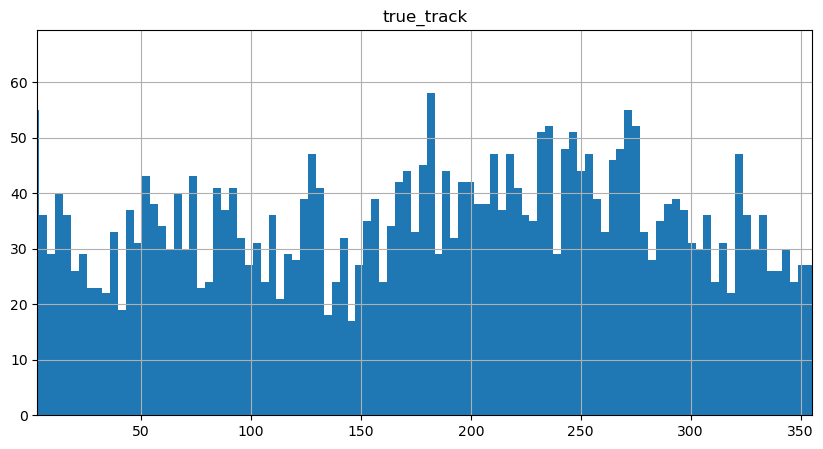

Количество пустых значений в vertical_rate: 584


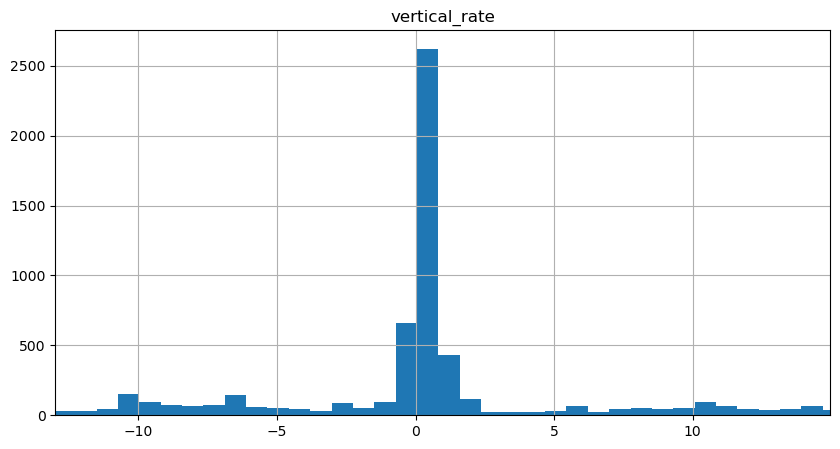

Количество пустых значений в geo_altitude: 701


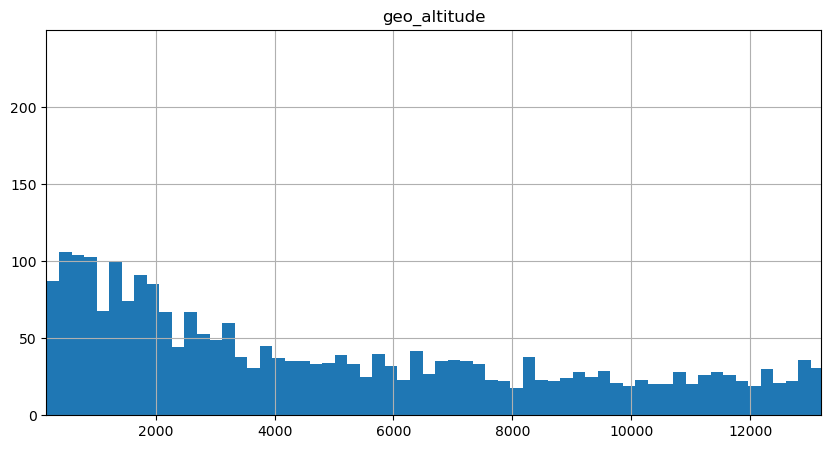

Количество пустых значений в position_source: 0


/tmp/ipykernel_5621/3617778694.py:47: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(p1_x, p99_x)


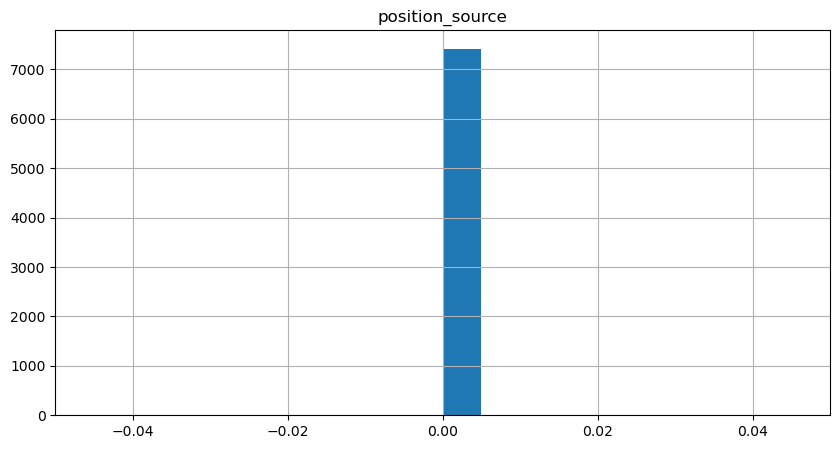

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

difference = 0
p1_x = 0
p99_x = 0

for col in numeric_columns:
    if ((col == 'time_position') or (col == 'last_contact')):
        value = pd.to_numeric(df[col], errors='coerce').dropna()
        value_min = value.min() / 1000
        difference = (value / 1000) - value_min

        p1_x = np.percentile(difference, 3)
        p99_x = np.percentile(difference, 99)
    else:
        value = pd.to_numeric(df[col], errors='coerce').dropna()

        negative_values = value[value < 0]
        positive_values = value[value >= 0]

        if not negative_values.empty:
            value_result_max = negative_values.max()
        else:
            value_result_max = 0

        if not positive_values.empty:
            value_result_min = positive_values.min()
        else:
            value_result_min = 0

        difference_left = value - value_result_max
        difference_right = value - value_result_min
        difference = difference_left + difference_right
        p1_x = np.percentile(difference_left, 1)
        p99_x = np.percentile(difference_right, 99)

    missing_count = df[col].isnull().sum()
    print(f'Количество пустых значений в {col}: {missing_count}')
    plt.figure(figsize = (10, 5))
    plt.hist(difference, bins = 200)
    plt.xlim(p1_x, p99_x)
    plt.grid(True)
    plt.title(col)
    plt.show()

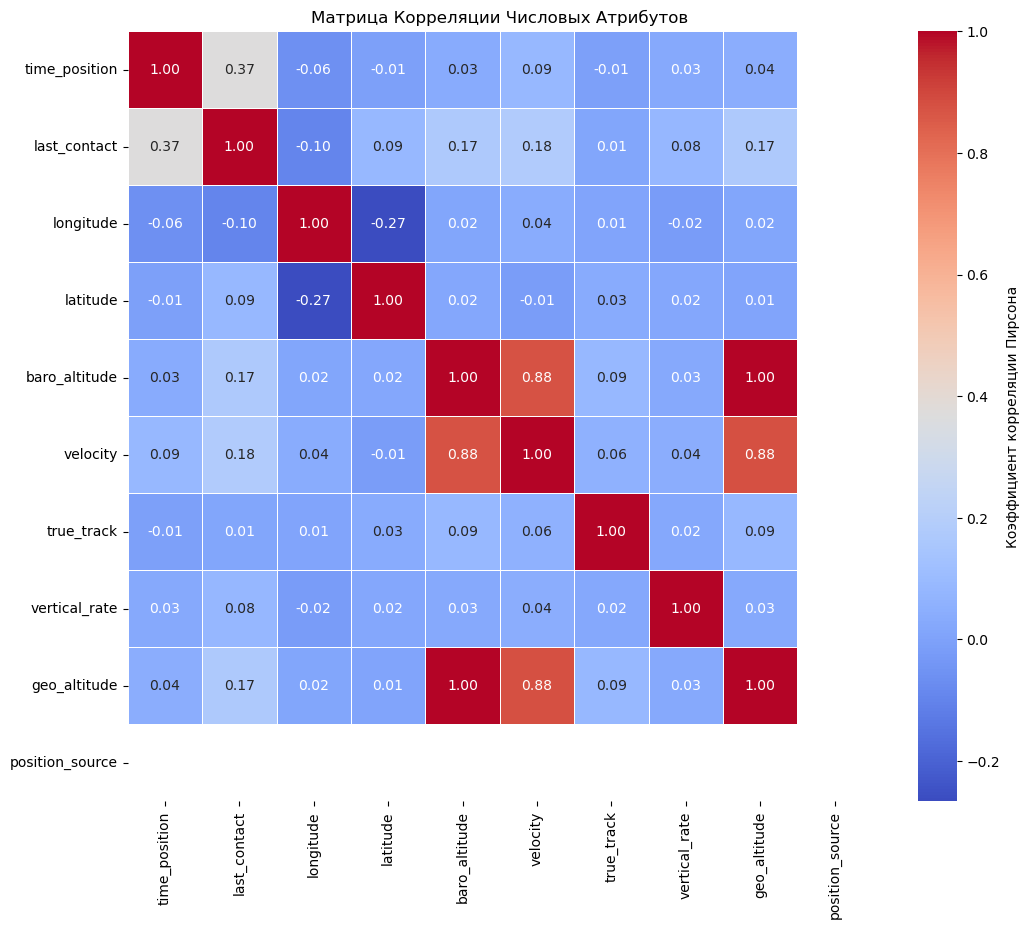

In [135]:
import seaborn as sns


# подмножество
df_numeric = df[numeric_columns]
df_corr_clean = df_numeric.dropna()

correlation_matrix = df_corr_clean.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,          # числовые значения корреляции
    cmap='coolwarm',     # красный (отрицательная), синий (положительная)
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Коэффициент корреляции Пирсона'}
)
plt.title('Матрица Корреляции Числовых Атрибутов')
plt.show()

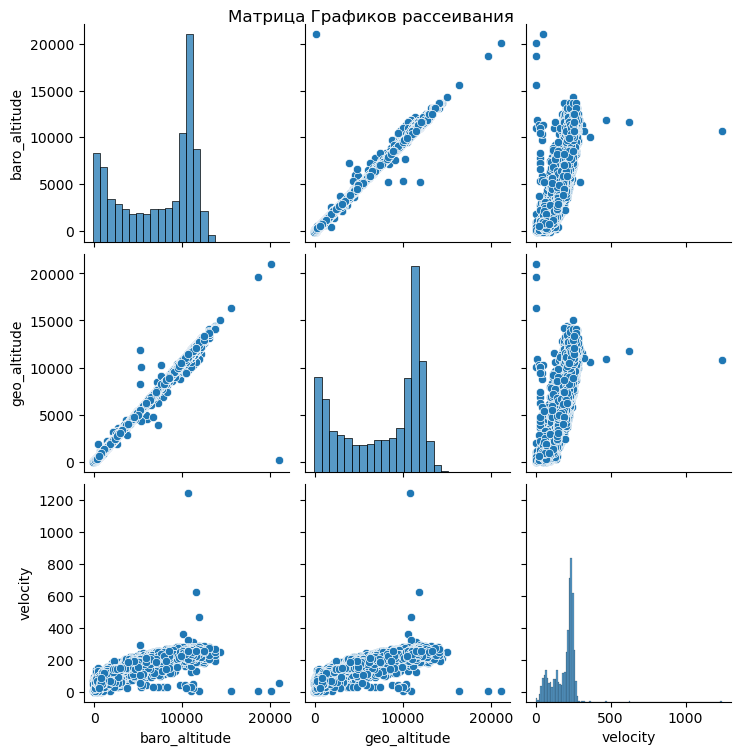

In [140]:
cols_correlation = ['baro_altitude', 'geo_altitude', 'velocity']

sns.pairplot(df_corr_clean[cols_correlation])
plt.suptitle('Матрица Графиков рассеивания', y =1)
plt.show()